# Notebook 4 - Relatorio Analitico e Decisao

Compara a criticidade de estoque prevista, os limiares de alerta/crítico e a necessidade de compra por modelo.

In [1]:
from pathlib import Path
import sys

NOTEBOOK_DIR = Path.cwd()
UTILS_DIR = next(
    (candidate / "utils" for candidate in [NOTEBOOK_DIR, *NOTEBOOK_DIR.parents] if (candidate / "utils").is_dir()),
    None,
)
if UTILS_DIR is None:
    raise RuntimeError("Nao encontrei ml/notebooks/utils. Execute o notebook dentro do repositorio Saltim.")
sys.path.insert(0, str(UTILS_DIR))

from two_stage_common import list_expected_artifacts, run_comparison_notebook


## Artefatos carregados

In [2]:
artifacts = list_expected_artifacts()
display(artifacts)

,model_uri,registered_model_name,run_id
0,runs:/07779156467c4b4590ce34d8e3e40e31/model,saltim_two_stage_01_knn_threshold_regression_k...,07779156467c4b4590ce34d8e3e40e31
1,runs:/a1a6b044027a4460b08f17cd7dab6c45/model,saltim_two_stage_02_linear_threshold_regressio...,a1a6b044027a4460b08f17cd7dab6c45
2,runs:/f4ba419e5f1c4821babb1404088c262c/model,saltim_two_stage_01_knn_threshold_regression_x...,f4ba419e5f1c4821babb1404088c262c
3,runs:/846050e3de5f4a7286ded5f3b97fc85b/model,saltim_two_stage_02_linear_threshold_regressio...,846050e3de5f4a7286ded5f3b97fc85b
4,runs:/ced84e0ca8004d51b8f54c4fc3267f1b/model,saltim_two_stage_01_knn_threshold_regression_g...,ced84e0ca8004d51b8f54c4fc3267f1b
5,runs:/ee3d86cbf4914a41a5914d6ec7aea281/model,saltim_two_stage_01_knn_purchase_alert_classif...,ee3d86cbf4914a41a5914d6ec7aea281
6,runs:/fb47270ced464e19aa03cf99de75fcc0/model,saltim_two_stage_02_linear_threshold_regressio...,fb47270ced464e19aa03cf99de75fcc0
7,runs:/189a5b11223844f8857fd5845c93883c/model,saltim_two_stage_01_knn_purchase_alert_classif...,189a5b11223844f8857fd5845c93883c
8,runs:/5f34c0266bae4c9eb4fd27aafa8ed00c/model,saltim_two_stage_02_linear_purchase_alert_clas...,5f34c0266bae4c9eb4fd27aafa8ed00c
9,runs:/06c934c41b864dd0b3a55f2812988c09/model,saltim_two_stage_02_linear_purchase_alert_clas...,06c934c41b864dd0b3a55f2812988c09


## Ranking estrategico: criticidade prevista e limiares

🏃 View run 04_two_stage_model_comparison - analysis at: http://localhost:5000/#/experiments/16/runs/64e9ec687d7f437d9e90cafe6c507d7b
🧪 View experiment at: http://localhost:5000/#/experiments/16
Modelos PKL carregados: 18


,rank_estrategico,notebook,family,stage,pipeline,model,rmse,mae,r2,accuracy,...,roc_auc,average_precision,f1_macro,precision_macro,recall_macro,taxa_ok,taxa_alerta_compra,taxa_necessita_compra,limiar_alerta_predito_medio,limiar_critico_predito_medio
0,1,03_tree_ensembles,Arvores,purchase_alert_classification,Arvores - purchase_alert_classification - Rand...,Random Forest Classifier,NaN,NaN,NaN,0.997856,...,0.999948,0.999708,0.995898,0.996086,0.995711,0.845461,0.154539,0.154539,NaN,NaN
1,2,02_linear,Linear,purchase_alert_classification,Linear - purchase_alert_classification - Gradi...,Gradient Boosting Classifier,NaN,NaN,NaN,0.997570,...,0.999796,0.994169,0.995362,0.994432,0.996297,0.844603,0.155397,0.155397,NaN,NaN
2,3,03_tree_ensembles,Arvores,purchase_alert_classification,Arvores - purchase_alert_classification - Grad...,Gradient Boosting Classifier,NaN,NaN,NaN,0.997570,...,0.999796,0.994169,0.995362,0.994432,0.996297,0.844603,0.155397,0.155397,NaN,NaN
3,4,01_knn,Distancia,purchase_alert_classification,Distancia - purchase_alert_classification - Gr...,Gradient Boosting Classifier,NaN,NaN,NaN,0.997570,...,0.999796,0.994169,0.995362,0.994432,0.996297,0.844603,0.155397,0.155397,NaN,NaN
4,5,01_knn,Distancia,purchase_alert_classification,Distancia - purchase_alert_classification - Xg...,XGBoost Classifier,NaN,NaN,NaN,0.997570,...,0.999960,0.999782,0.995345,0.996285,0.994409,0.846033,0.153967,0.153967,NaN,NaN
5,6,02_linear,Linear,purchase_alert_classification,Linear - purchase_alert_classification - Xgboost,XGBoost Classifier,NaN,NaN,NaN,0.997570,...,0.999960,0.999782,0.995345,0.996285,0.994409,0.846033,0.153967,0.153967,NaN,NaN
6,7,03_tree_ensembles,Arvores,purchase_alert_classification,Arvores - purchase_alert_classification - Xgboost,XGBoost Classifier,NaN,NaN,NaN,0.997570,...,0.999960,0.999782,0.995345,0.996285,0.994409,0.846033,0.153967,0.153967,NaN,NaN
7,8,02_linear,Linear,purchase_alert_classification,Linear - purchase_alert_classification - Linear,Logistic Regression,NaN,NaN,NaN,0.985132,...,0.998877,0.992742,0.972056,0.964284,0.980257,0.838742,0.161258,0.161258,NaN,NaN
8,9,01_knn,Distancia,purchase_alert_classification,Distancia - purchase_alert_classification - Knn,KNN Classifier,NaN,NaN,NaN,0.982988,...,0.990533,0.969034,0.966934,0.974913,0.959356,0.851465,0.148535,0.148535,NaN,NaN
9,10,03_tree_ensembles,Arvores,threshold_regression,Arvores - threshold_regression - Random Forest,Random Forest Regressor,0.046589,0.035292,0.778663,0.998856,...,NaN,NaN,0.997815,0.997440,0.998191,0.845032,0.154968,0.154968,0.328618,0.178618


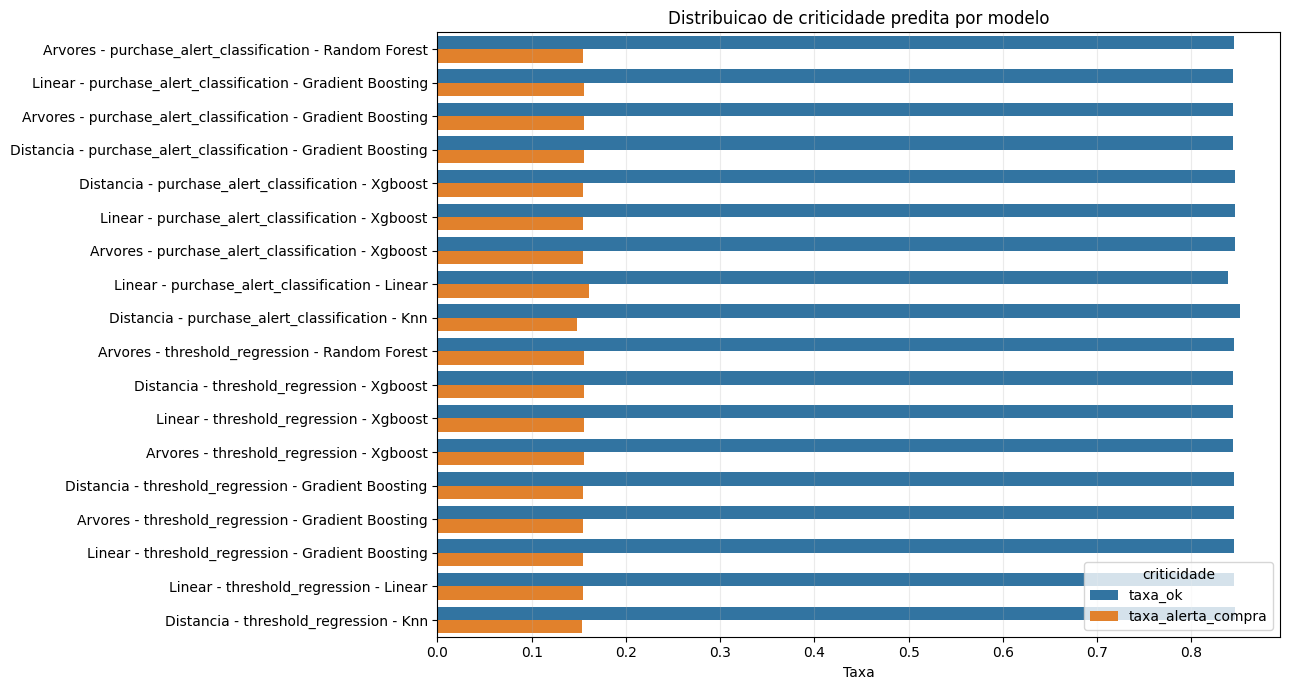

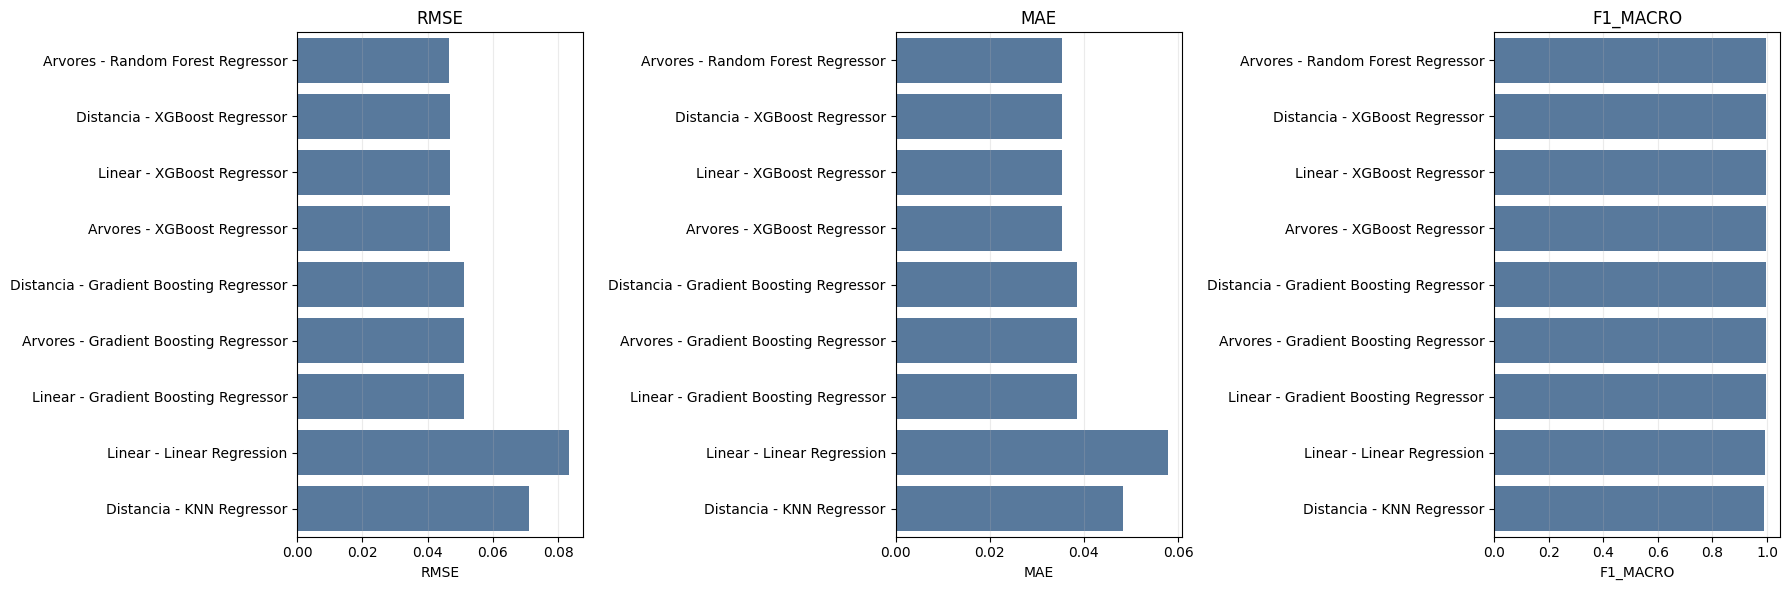

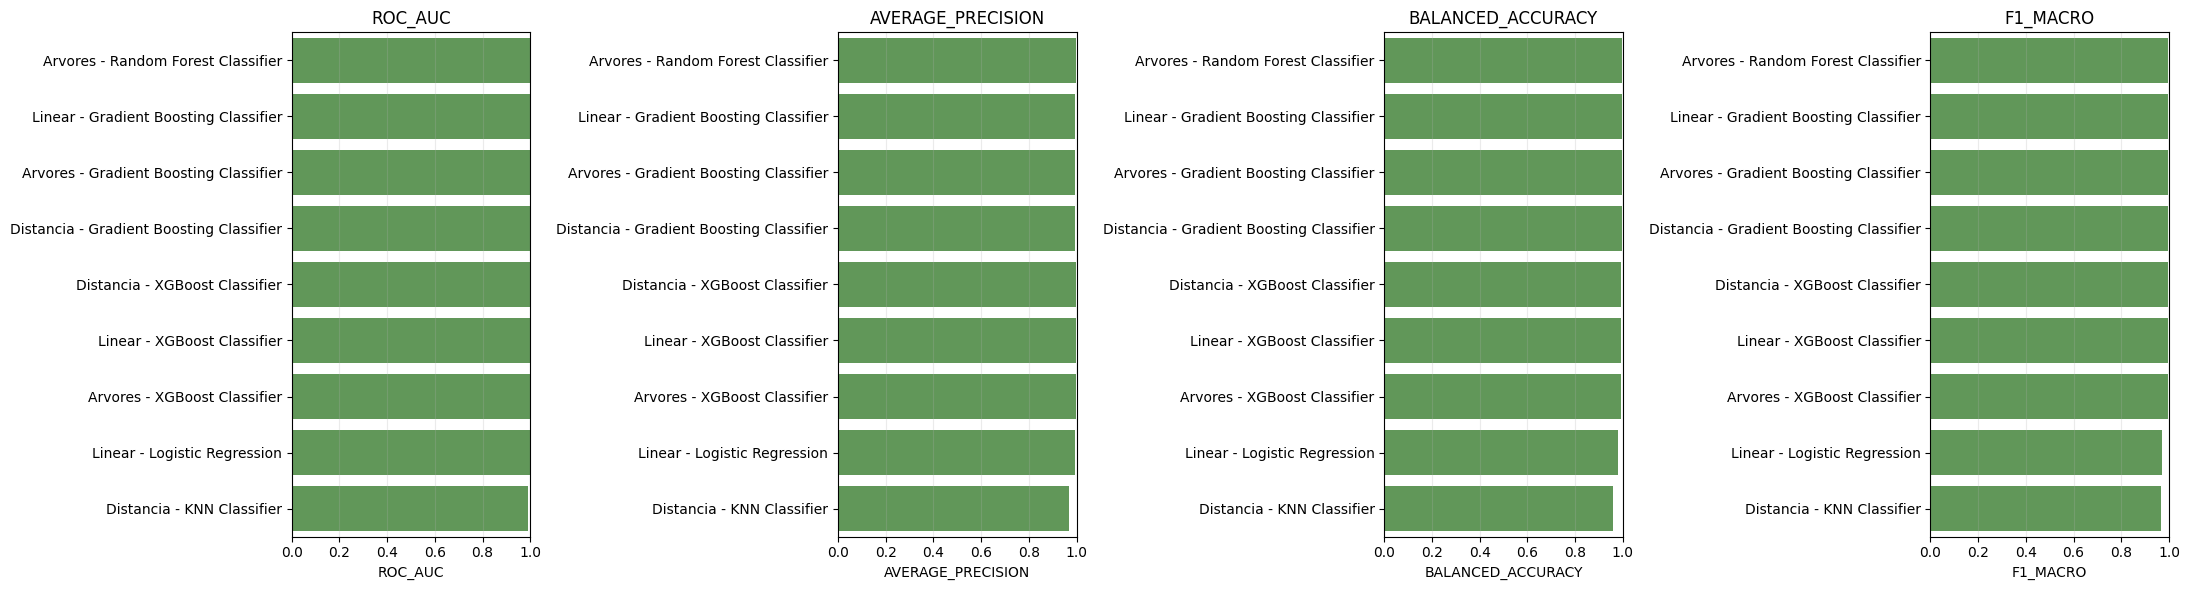

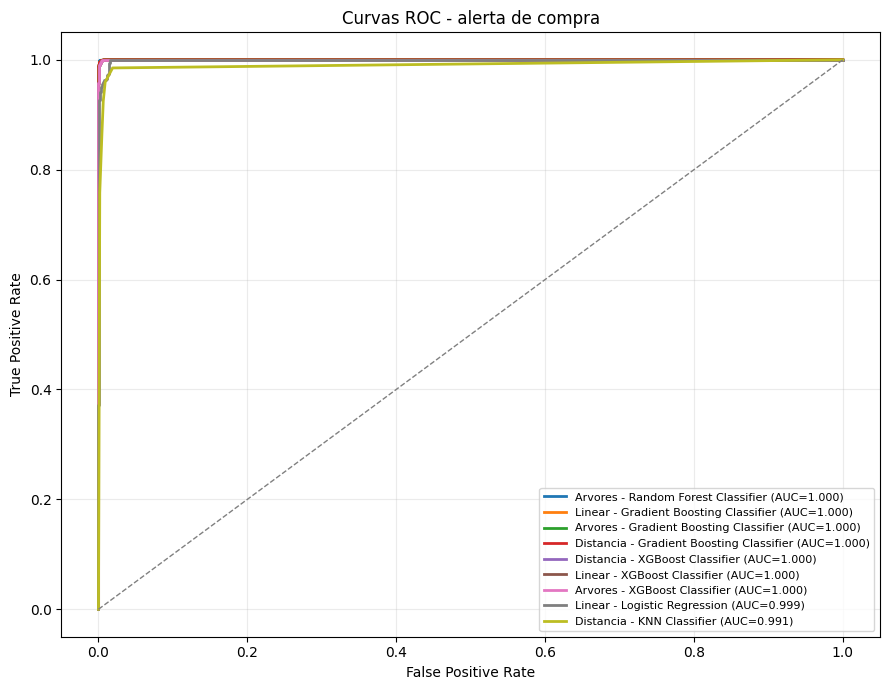

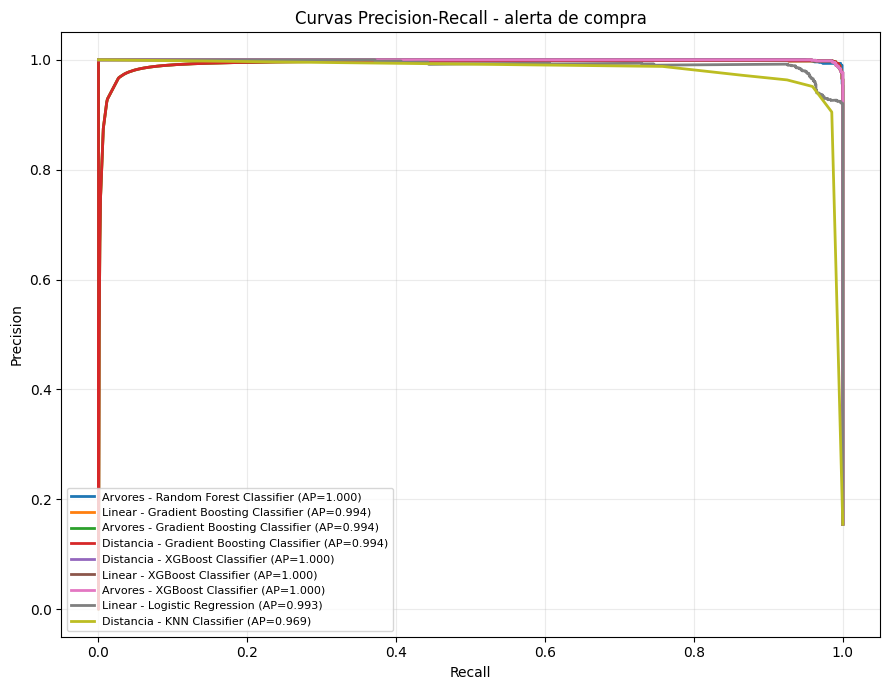

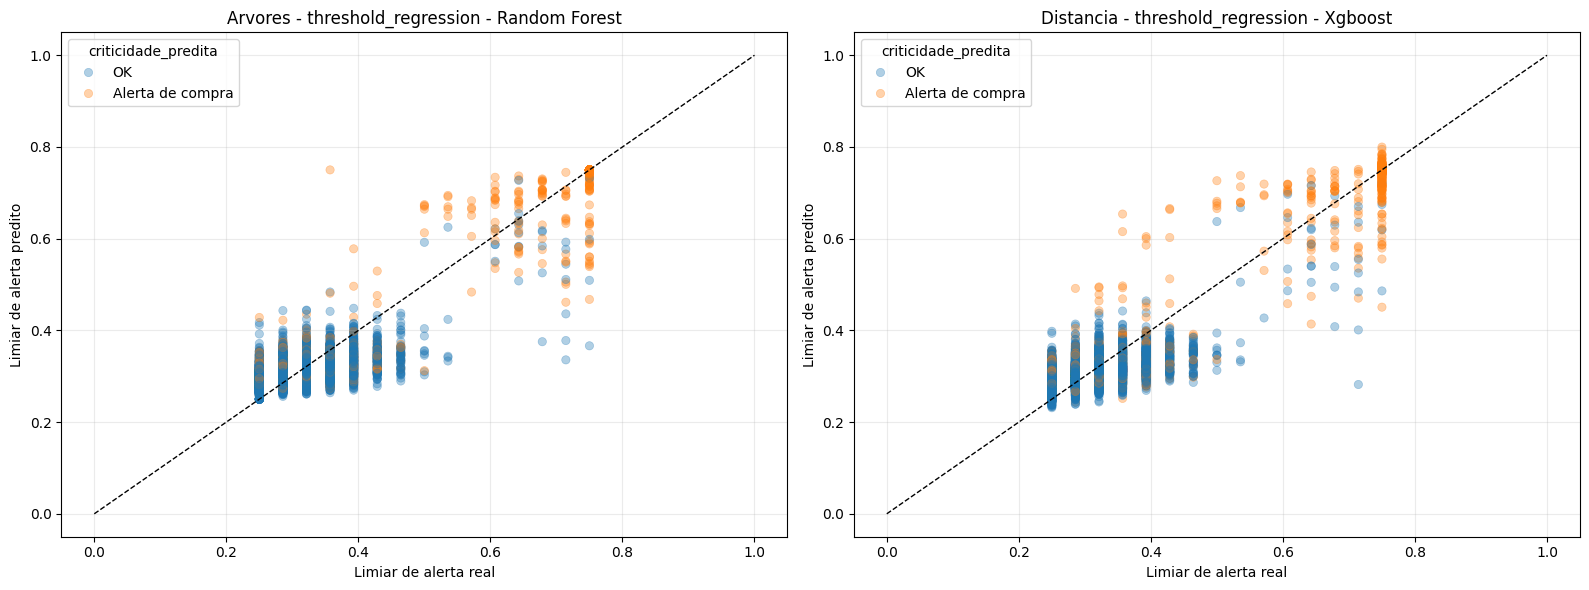

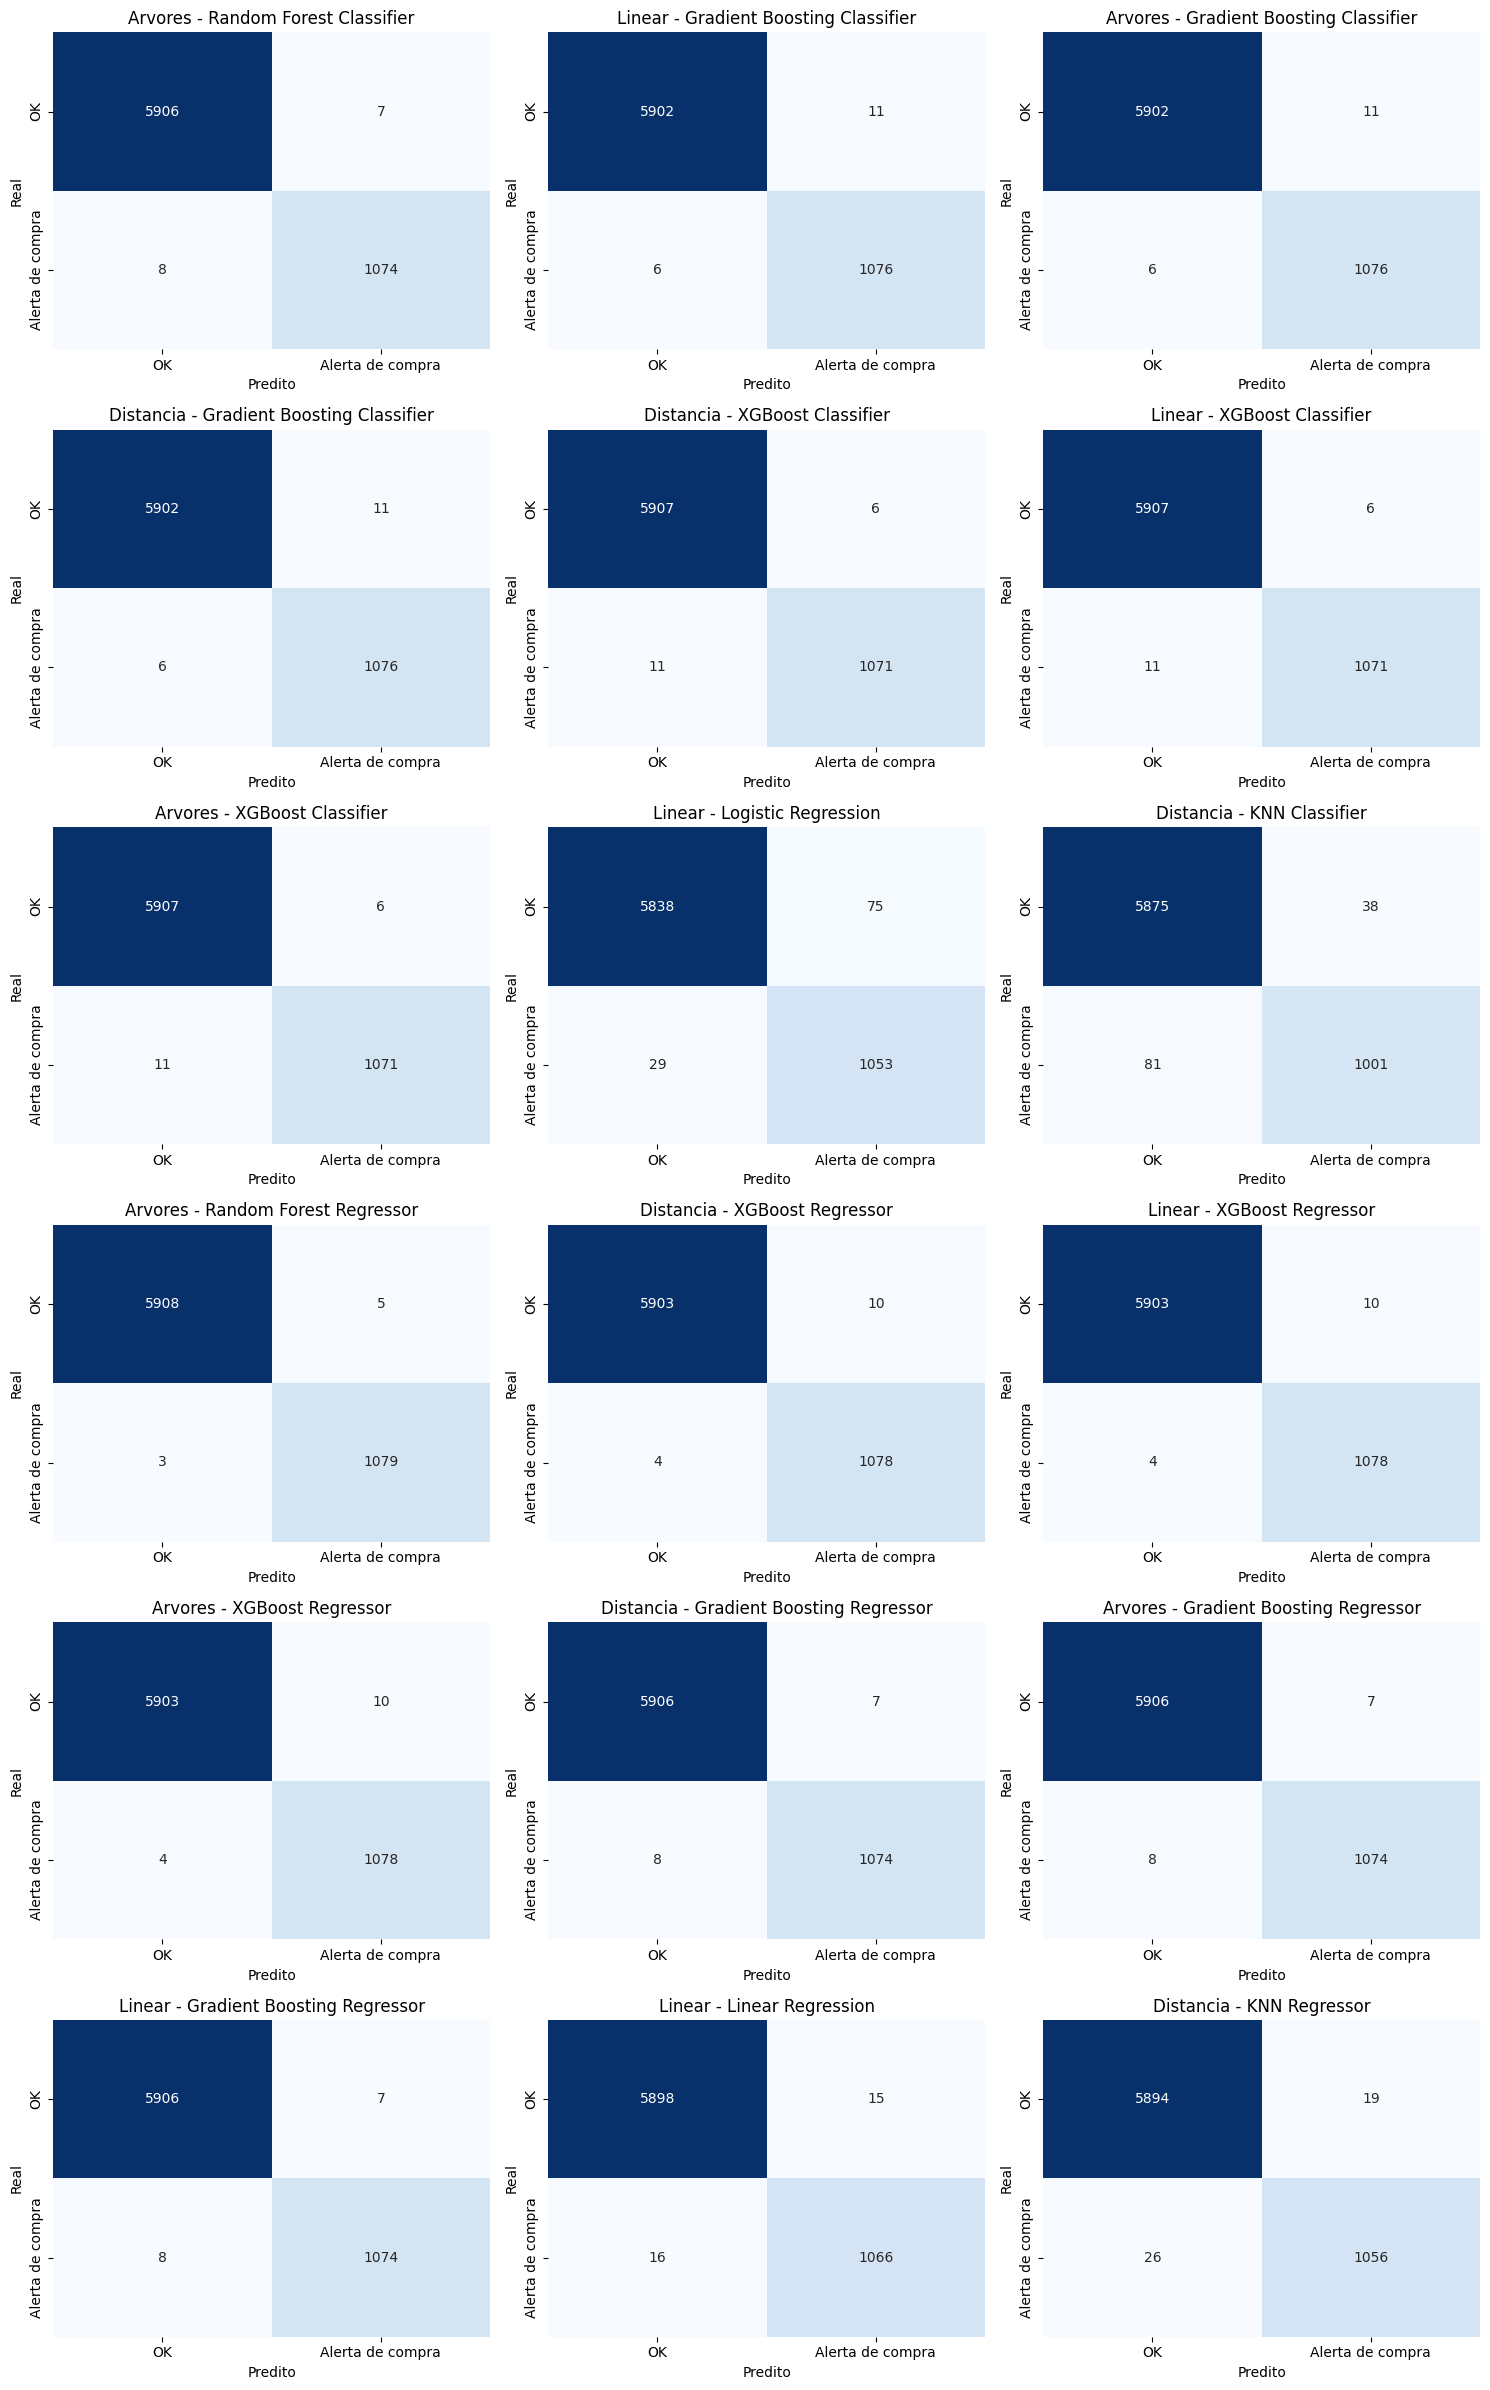

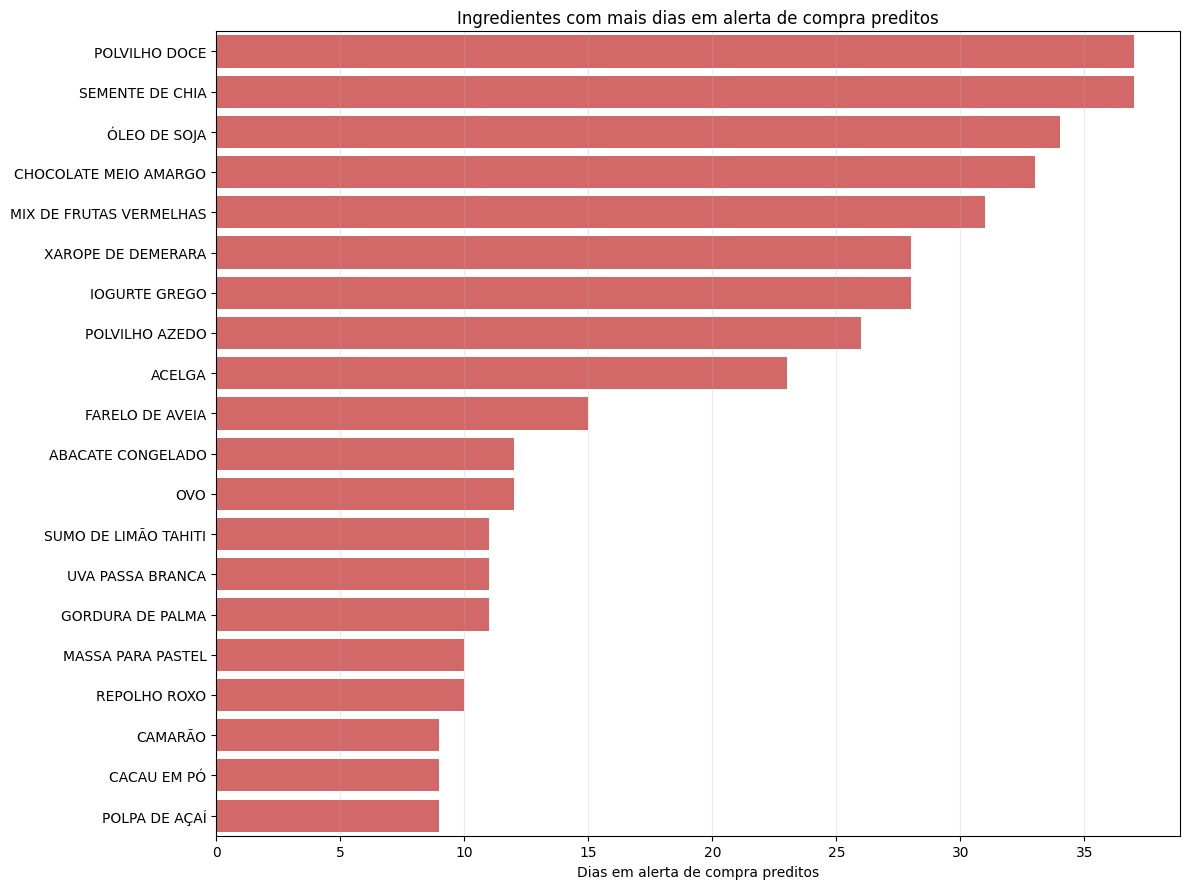

In [3]:
comparison = run_comparison_notebook()

print(f"Modelos PKL carregados: {comparison['models_loaded']}")
display(comparison["operational_metrics"])

## Recomendacoes operacionais detalhadas

In [4]:
display(comparison["operational_recommendations"].head(25))

,pipeline,stage,notebook,family,model,ingredient_id,date,nome_ingrediente,categoria,unidade,...,y_criticidade_nivel_ajustado,limiar_alerta_real_pct,limiar_alerta_predito_pct,limiar_critico_predito_pct,criticidade_real,criticidade_predita,probabilidade_alerta_compra,score_alerta_compra,necessita_compra,erro_limiar_alerta_pct
0,Arvores - purchase_alert_classification - Rand...,purchase_alert_classification,03_tree_ensembles,Arvores,Random Forest Classifier,ING0227,2026-03-30,GENGIBRE,Temperos e Especiarias,KG,...,OK,0.285714,NaN,NaN,OK,OK,0.00,0.00,False,NaN
1,Arvores - purchase_alert_classification - Rand...,purchase_alert_classification,03_tree_ensembles,Arvores,Random Forest Classifier,ING0104,2026-01-21,CEBOLA ROXA,Legumes e Verduras,KG,...,Alerta de compra,0.428571,NaN,NaN,Alerta de compra,Alerta de compra,0.88,0.88,True,NaN
2,Arvores - purchase_alert_classification - Rand...,purchase_alert_classification,03_tree_ensembles,Arvores,Random Forest Classifier,ING0110,2026-04-27,MIX DE COGUMELOS,Legumes e Verduras,KG,...,OK,0.357143,NaN,NaN,OK,OK,0.00,0.00,False,NaN
3,Arvores - purchase_alert_classification - Rand...,purchase_alert_classification,03_tree_ensembles,Arvores,Random Forest Classifier,ING0163,2026-01-05,OVO,Proteínas,UND,...,OK,0.357143,NaN,NaN,OK,OK,0.00,0.00,False,NaN
4,Arvores - purchase_alert_classification - Rand...,purchase_alert_classification,03_tree_ensembles,Arvores,Random Forest Classifier,ING0114,2026-03-30,REPOLHO ROXO,Legumes e Verduras,KG,...,OK,0.392857,NaN,NaN,OK,OK,0.00,0.00,False,NaN
5,Arvores - purchase_alert_classification - Rand...,purchase_alert_classification,03_tree_ensembles,Arvores,Random Forest Classifier,ING0111,2026-02-07,MIX DE FOLHAS,Legumes e Verduras,KG,...,OK,0.285714,NaN,NaN,OK,OK,0.00,0.00,False,NaN
6,Arvores - purchase_alert_classification - Rand...,purchase_alert_classification,03_tree_ensembles,Arvores,Random Forest Classifier,ING0016,2026-05-14,ESSÊNCIA DE BAUNILHA,Bebidas e Bases,L,...,OK,0.321429,NaN,NaN,OK,OK,0.00,0.00,False,NaN
7,Arvores - purchase_alert_classification - Rand...,purchase_alert_classification,03_tree_ensembles,Arvores,Random Forest Classifier,ING0166,2026-02-21,SALMÃO DEFUMADO,Proteínas,KG,...,OK,0.285714,NaN,NaN,OK,OK,0.00,0.00,False,NaN
8,Arvores - purchase_alert_classification - Rand...,purchase_alert_classification,03_tree_ensembles,Arvores,Random Forest Classifier,ING0133,2026-02-23,CASTANHA DE CAJU,Nozes e Sementes,KG,...,OK,0.392857,NaN,NaN,OK,OK,0.04,0.04,False,NaN
9,Arvores - purchase_alert_classification - Rand...,purchase_alert_classification,03_tree_ensembles,Arvores,Random Forest Classifier,ING0087,2026-03-06,LEITE EM PÓ,Laticínios,KG,...,OK,0.285714,NaN,NaN,OK,OK,0.00,0.00,False,NaN


## Divergencia por ingrediente no melhor modelo operacional

In [5]:
display(comparison["operational_by_ingredient"].head(25))

,pipeline,ingredient_id,nome_ingrediente,categoria,unidade,observacoes,dias_ok_preditos,dias_alerta_compra_preditos,dias_necessita_compra,cobertura_estoque_pct_min,cobertura_estoque_pct_media,limiar_alerta_predito_pct_medio,limiar_critico_predito_pct_medio,taxa_necessita_compra
0,Arvores - purchase_alert_classification - Rand...,ING0074,POLVILHO DOCE,"Grãos, Farinhas e Massas",KG,37,0,37,37,0.000000,0.033453,NaN,NaN,1.000000
1,Arvores - purchase_alert_classification - Rand...,ING0146,SEMENTE DE CHIA,Nozes e Sementes,KG,43,6,37,37,0.000000,0.341931,NaN,NaN,0.860465
2,Arvores - purchase_alert_classification - Rand...,ING0244,ÓLEO DE SOJA,Óleos e Gorduras,L,35,1,34,34,0.000000,0.072722,NaN,NaN,0.971429
3,Arvores - purchase_alert_classification - Rand...,ING0031,CHOCOLATE MEIO AMARGO,Chocolates e Cacau,KG,33,0,33,33,0.070131,0.103673,NaN,NaN,1.000000
4,Arvores - purchase_alert_classification - Rand...,ING0054,MIX DE FRUTAS VERMELHAS,Frutas Secas e Congeladas,KG,40,9,31,31,0.000000,0.334224,NaN,NaN,0.775000
5,Arvores - purchase_alert_classification - Rand...,ING0009,XAROPE DE DEMERARA,Açúcares e Mel,KG,28,0,28,28,0.000000,0.101756,NaN,NaN,1.000000
6,Arvores - purchase_alert_classification - Rand...,ING0085,IOGURTE GREGO,Laticínios,L,28,0,28,28,0.000000,0.042926,NaN,NaN,1.000000
7,Arvores - purchase_alert_classification - Rand...,ING0073,POLVILHO AZEDO,"Grãos, Farinhas e Massas",KG,26,0,26,26,0.000000,0.041996,NaN,NaN,1.000000
8,Arvores - purchase_alert_classification - Rand...,ING0098,ACELGA,Legumes e Verduras,KG,34,11,23,23,0.000000,0.350121,NaN,NaN,0.676471
9,Arvores - purchase_alert_classification - Rand...,ING0064,FARELO DE AVEIA,"Grãos, Farinhas e Massas",KG,22,7,15,15,0.000000,0.264635,NaN,NaN,0.681818


## Visualizacoes operacionais

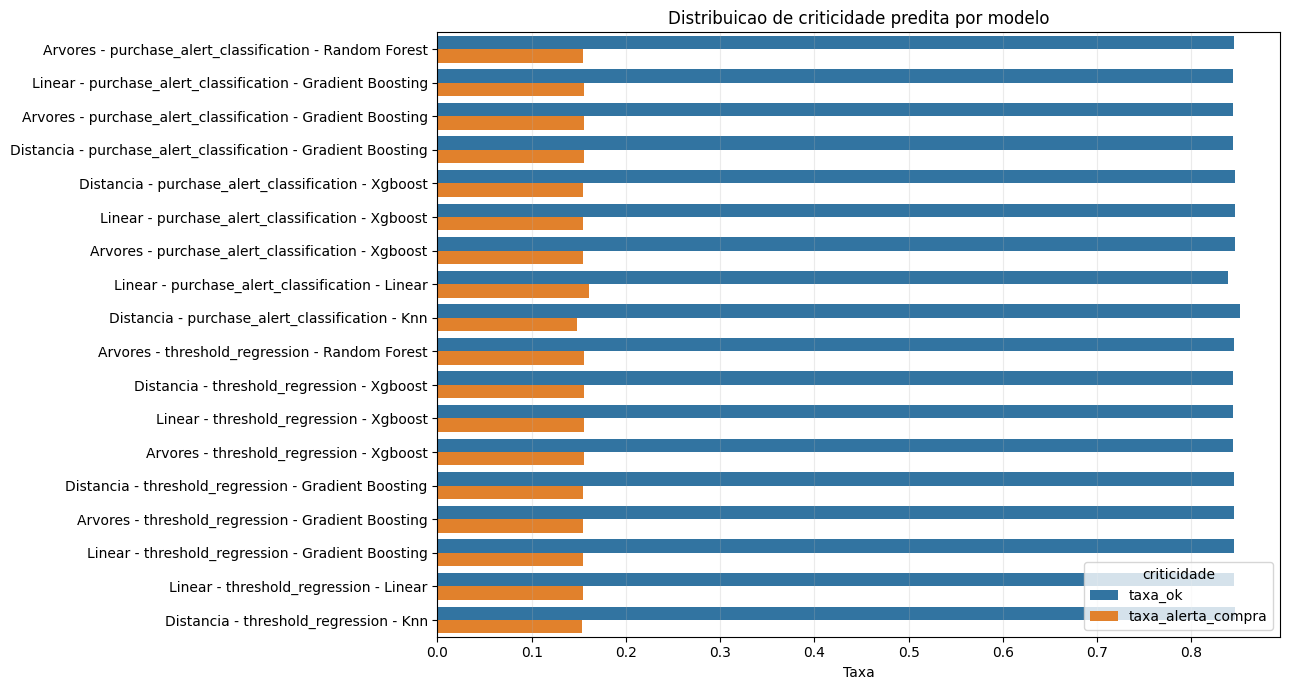

In [6]:
comparison["figures"]["criticality_distribution"]

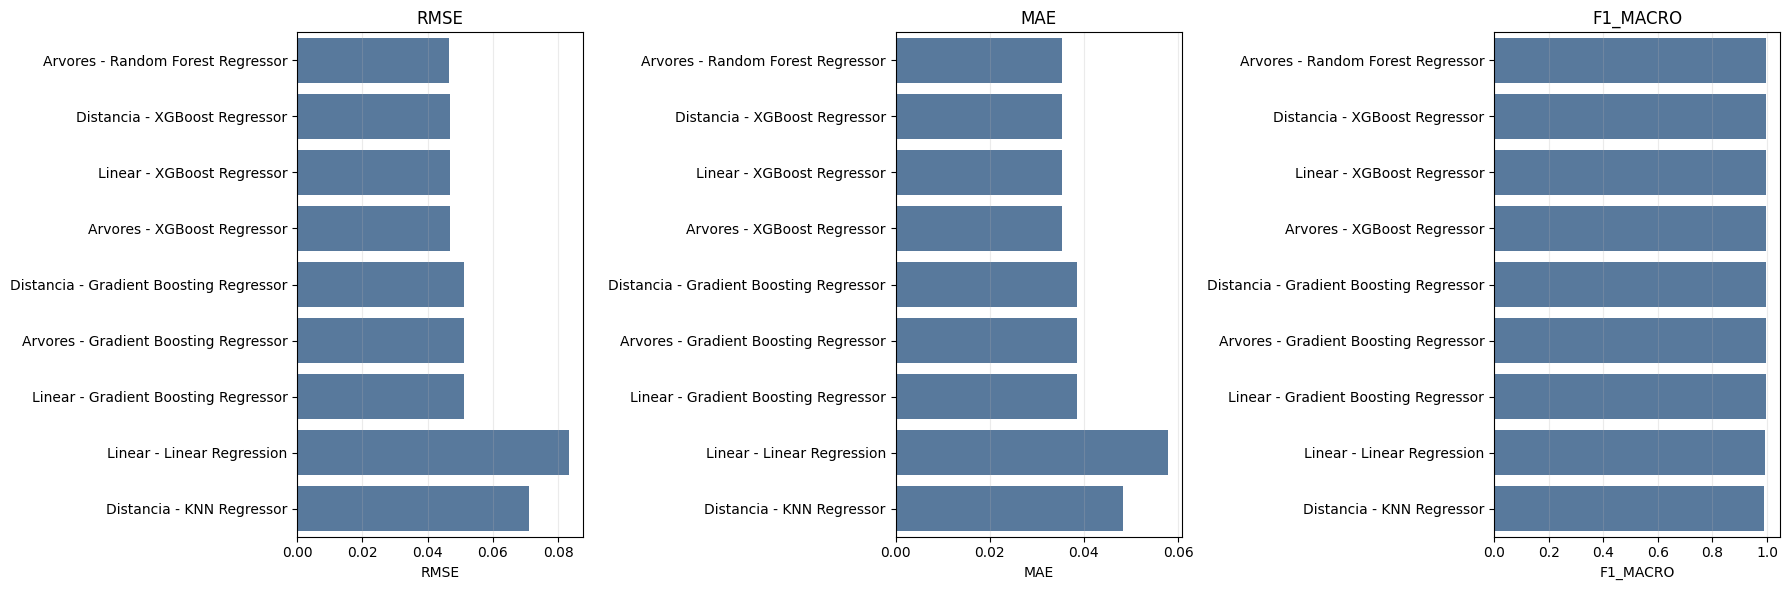

In [7]:
comparison["figures"]["threshold_metric_bars"]

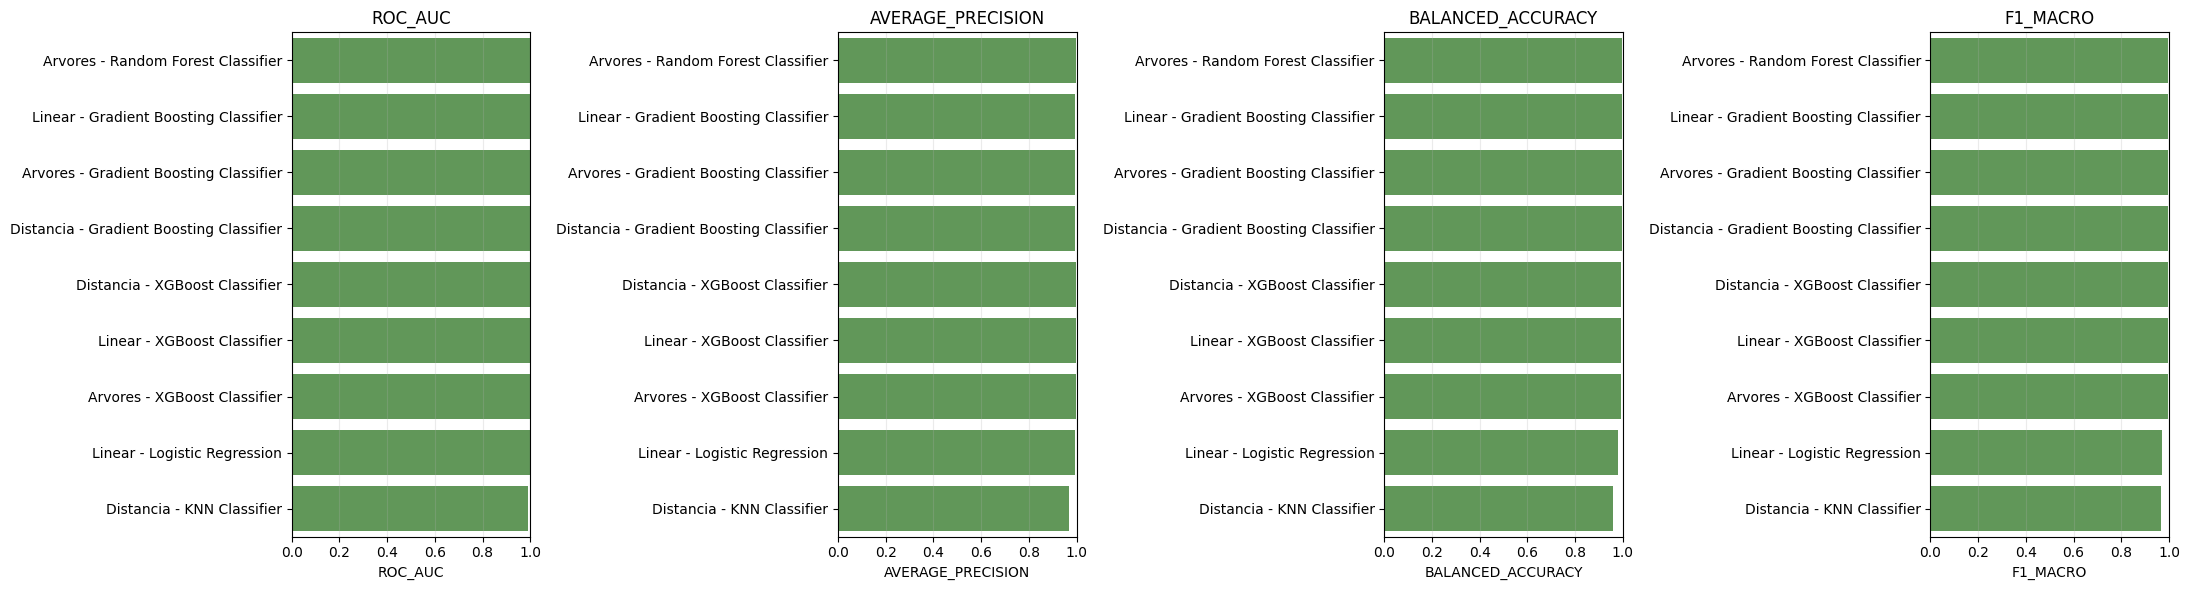

In [8]:
comparison["figures"]["classifier_metric_bars"]

## Curvas dos classificadores de alerta de compra


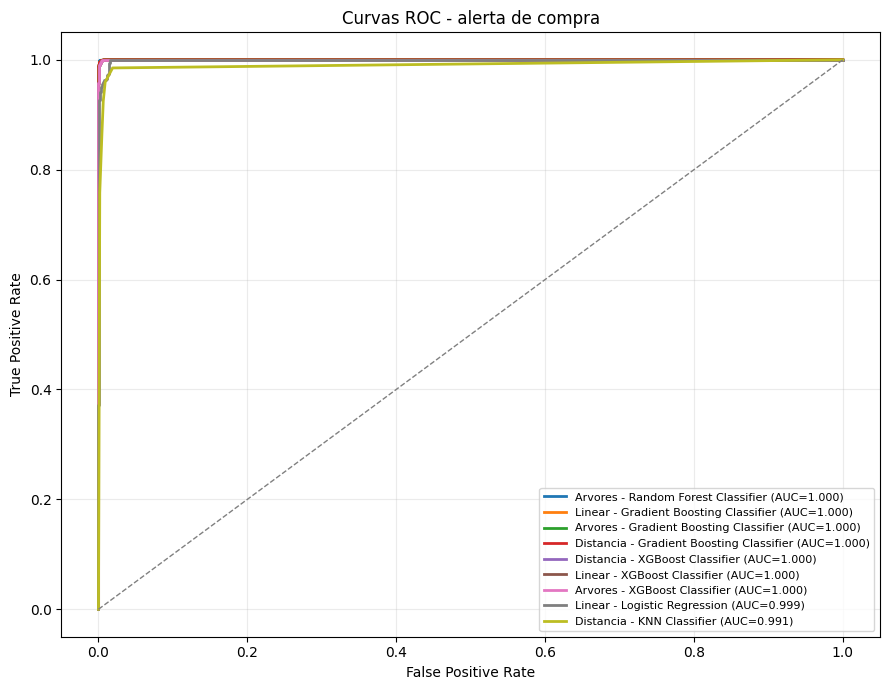

In [9]:
comparison["figures"]["purchase_alert_roc_curves"]

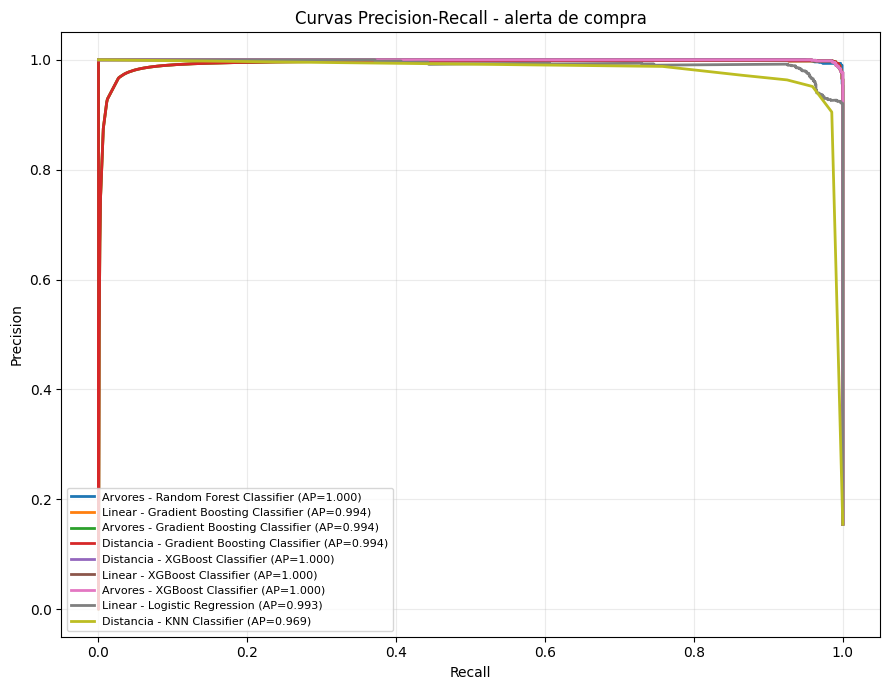

In [10]:
comparison["figures"]["purchase_alert_precision_recall_curves"]

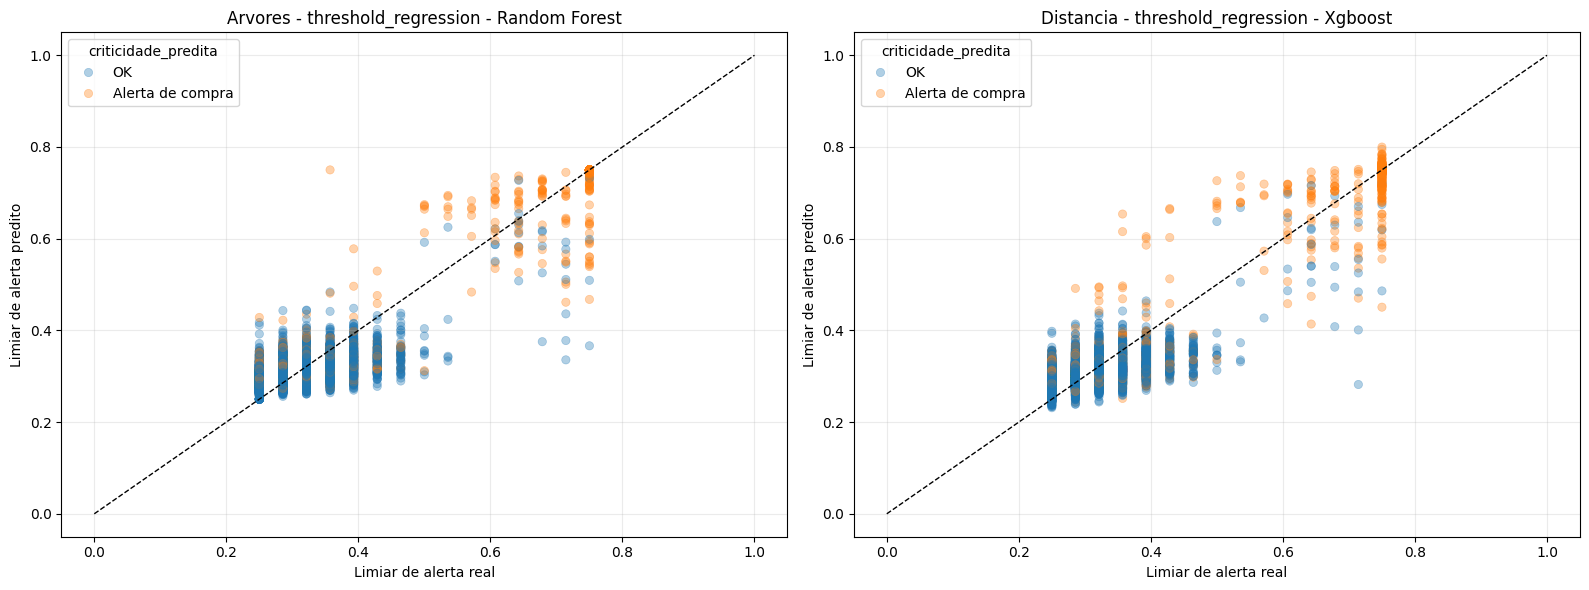

In [11]:
comparison["figures"]["threshold_scatter"]

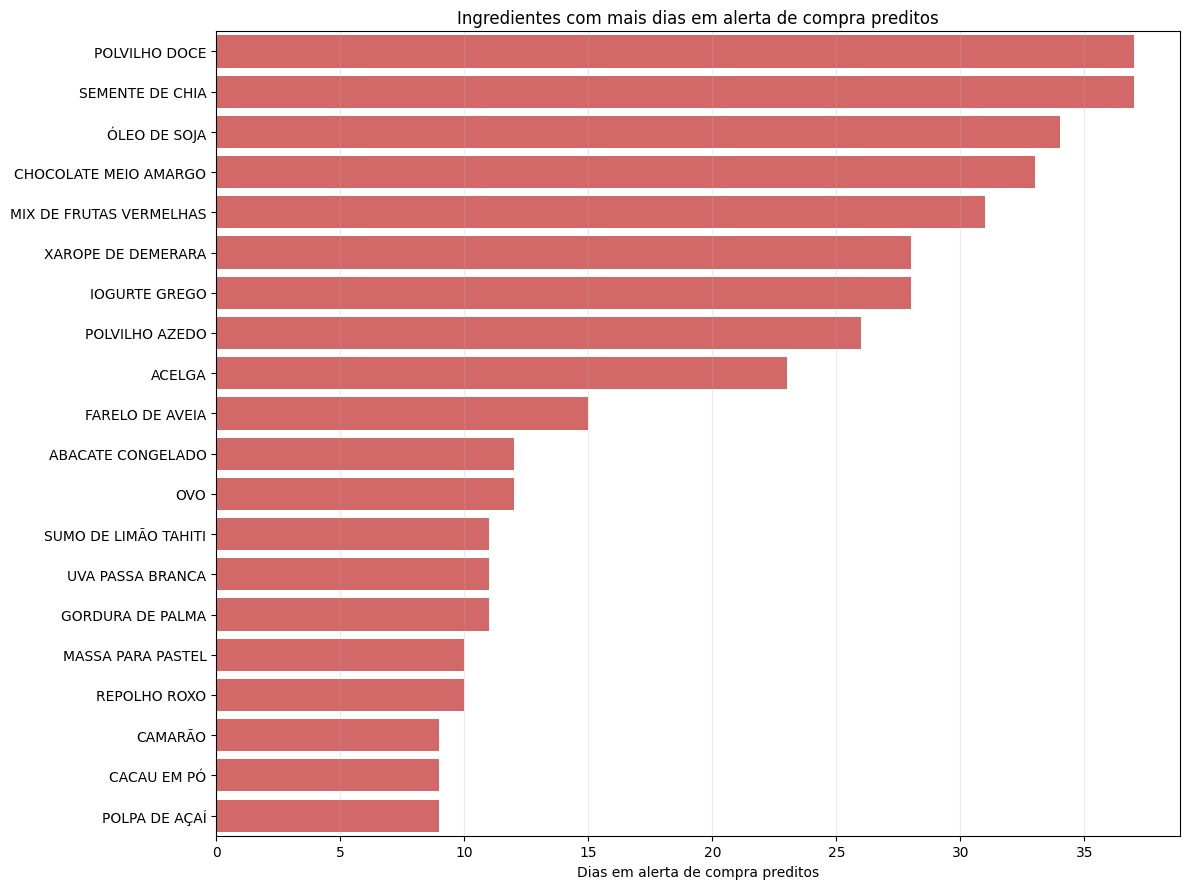

In [12]:
comparison["figures"]["top_critical_ingredients"]

## Metricas tecnicas de apoio

In [13]:
display(comparison["decision_table"])


,rank,notebook,family,stage,model,accuracy,balanced_accuracy,f1_macro,precision_macro,recall_macro,...,average_precision,rmse,mae,r2,run_id,model_uri,registered_model_name,metric_artifact_path,prediction_artifact_path,summary_artifact_path
0,1,03_tree_ensembles,Arvores,purchase_alert_classification,Random Forest Classifier,0.997856,0.995711,0.995898,0.996086,0.995711,...,0.999708,NaN,NaN,NaN,50486c6cf6ef4050bb465bb8888a0a81,runs:/50486c6cf6ef4050bb465bb8888a0a81/model,saltim_two_stage_03_tree_ensembles_purchase_al...,evaluation/03_tree_ensembles_random_forest_cla...,evaluation/03_tree_ensembles_random_forest_cla...,evaluation/03_tree_ensembles_run_summary.json
1,2,02_linear,Linear,purchase_alert_classification,Gradient Boosting Classifier,0.997570,0.996297,0.995362,0.994432,0.996297,...,0.994169,NaN,NaN,NaN,479e30ea6439452fa4e2b6defd31d6e8,runs:/479e30ea6439452fa4e2b6defd31d6e8/model,saltim_two_stage_02_linear_purchase_alert_clas...,evaluation/02_linear_gradient_boosting_classif...,evaluation/02_linear_gradient_boosting_classif...,evaluation/02_linear_run_summary.json
2,3,03_tree_ensembles,Arvores,purchase_alert_classification,Gradient Boosting Classifier,0.997570,0.996297,0.995362,0.994432,0.996297,...,0.994169,NaN,NaN,NaN,d0c2092912a74b31bac9c3dea9205d51,runs:/d0c2092912a74b31bac9c3dea9205d51/model,saltim_two_stage_03_tree_ensembles_purchase_al...,evaluation/03_tree_ensembles_gradient_boosting...,evaluation/03_tree_ensembles_gradient_boosting...,evaluation/03_tree_ensembles_run_summary.json
3,4,01_knn,Distancia,purchase_alert_classification,Gradient Boosting Classifier,0.997570,0.996297,0.995362,0.994432,0.996297,...,0.994169,NaN,NaN,NaN,1011cbe9e49c4b26b8d630efb617d0f6,runs:/1011cbe9e49c4b26b8d630efb617d0f6/model,saltim_two_stage_01_knn_purchase_alert_classif...,evaluation/01_knn_gradient_boosting_classifier...,evaluation/01_knn_gradient_boosting_classifier...,evaluation/01_knn_run_summary.json
4,5,01_knn,Distancia,purchase_alert_classification,XGBoost Classifier,0.997570,0.994409,0.995345,0.996285,0.994409,...,0.999782,NaN,NaN,NaN,189a5b11223844f8857fd5845c93883c,runs:/189a5b11223844f8857fd5845c93883c/model,saltim_two_stage_01_knn_purchase_alert_classif...,evaluation/01_knn_xgboost_classifier_purchase_...,evaluation/01_knn_xgboost_classifier_purchase_...,evaluation/01_knn_run_summary.json
5,6,02_linear,Linear,purchase_alert_classification,XGBoost Classifier,0.997570,0.994409,0.995345,0.996285,0.994409,...,0.999782,NaN,NaN,NaN,06c934c41b864dd0b3a55f2812988c09,runs:/06c934c41b864dd0b3a55f2812988c09/model,saltim_two_stage_02_linear_purchase_alert_clas...,evaluation/02_linear_xgboost_classifier_purcha...,evaluation/02_linear_xgboost_classifier_purcha...,evaluation/02_linear_run_summary.json
6,7,03_tree_ensembles,Arvores,purchase_alert_classification,XGBoost Classifier,0.997570,0.994409,0.995345,0.996285,0.994409,...,0.999782,NaN,NaN,NaN,8ef094e762b34fb293e9917c1ad2d321,runs:/8ef094e762b34fb293e9917c1ad2d321/model,saltim_two_stage_03_tree_ensembles_purchase_al...,evaluation/03_tree_ensembles_xgboost_classifie...,evaluation/03_tree_ensembles_xgboost_classifie...,evaluation/03_tree_ensembles_run_summary.json
7,8,02_linear,Linear,purchase_alert_classification,Logistic Regression,0.985132,0.980257,0.972056,0.964284,0.980257,...,0.992742,NaN,NaN,NaN,5f34c0266bae4c9eb4fd27aafa8ed00c,runs:/5f34c0266bae4c9eb4fd27aafa8ed00c/model,saltim_two_stage_02_linear_purchase_alert_clas...,evaluation/02_linear_logistic_regression_purch...,evaluation/02_linear_logistic_regression_purch...,evaluation/02_linear_run_summary.json
8,9,01_knn,Distancia,purchase_alert_classification,KNN Classifier,0.982988,0.959356,0.966934,0.974913,0.959356,...,0.969034,NaN,NaN,NaN,ee3d86cbf4914a41a5914d6ec7aea281,runs:/ee3d86cbf4914a41a5914d6ec7aea281/model,saltim_two_stage_01_knn_purchase_alert_classif...,evaluation/01_knn_knn_classifier_purchase_aler...,evaluation/01_knn_knn_classifier_purchase_aler...,evaluation/01_knn_run_summary.json
9,10,03_tree_ensembles,Arvores,

## Visualizacoes tecnicas de criticidade


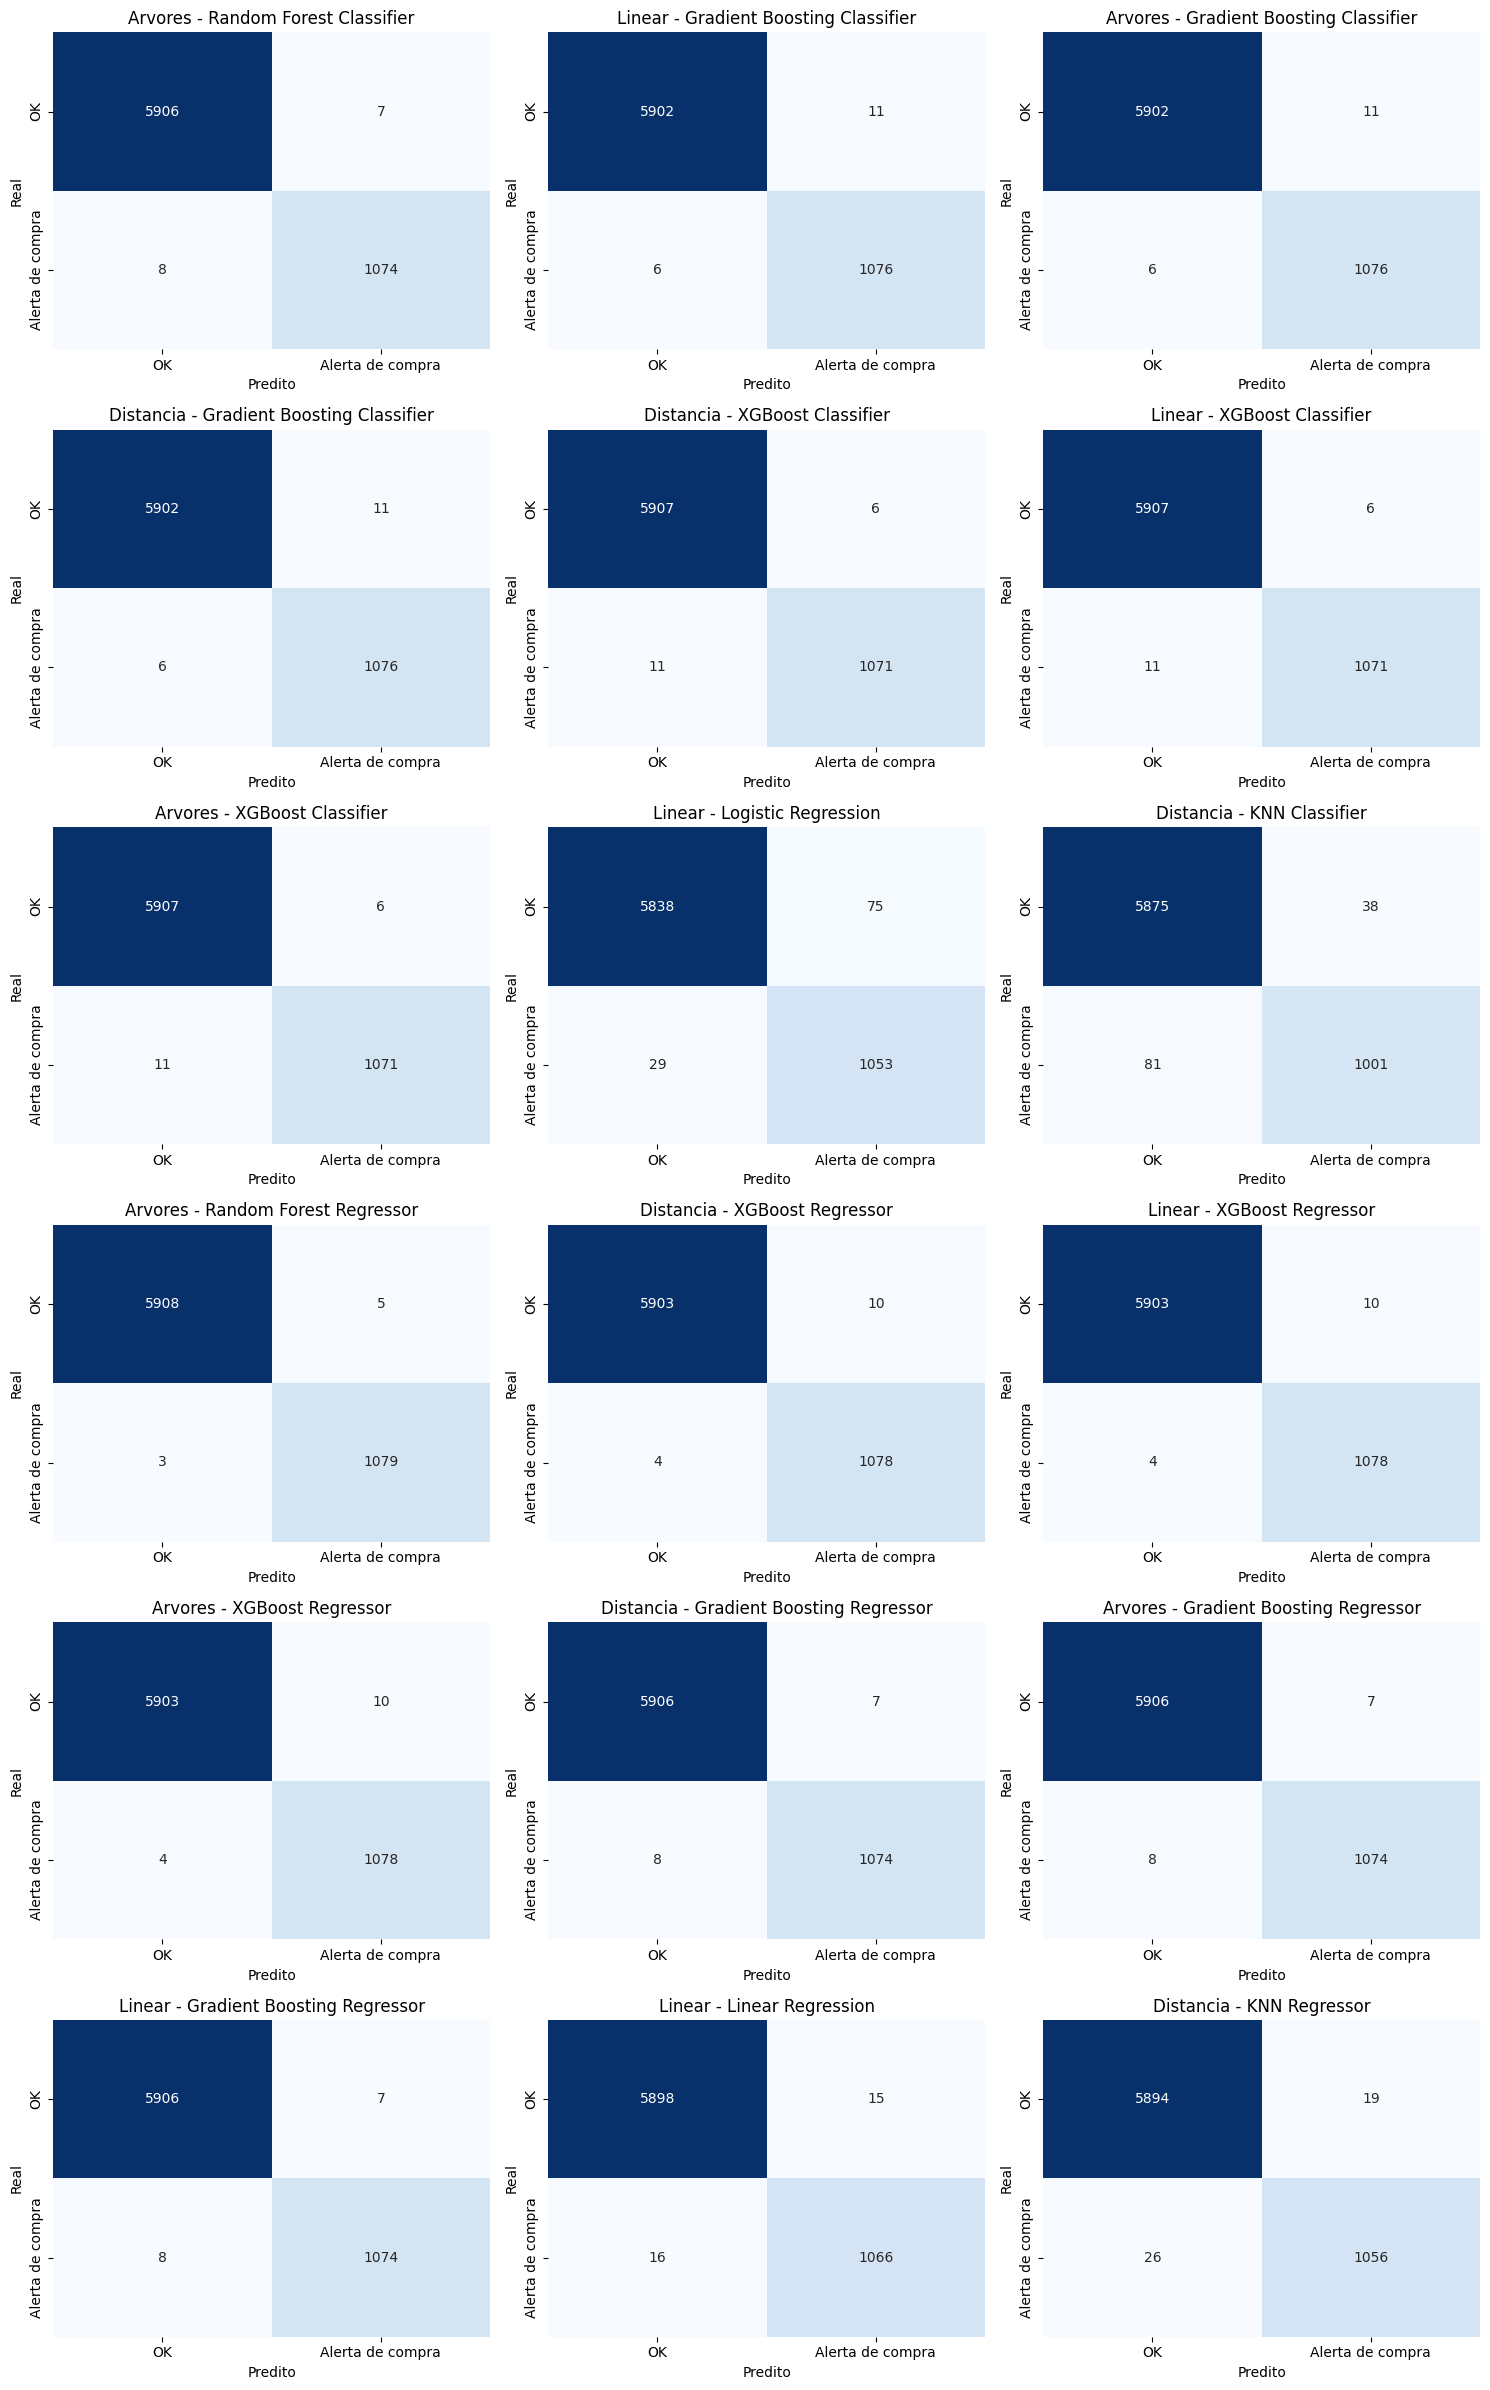

In [14]:
comparison["figures"]["confusion_matrices"]